# AI Incident Database (AIID) — Reproducible Research Notebook

**Hackathon:** TAI Hackathon — Problem Statement 5
**Data source:** [AI Incident Database](https://incidentdatabase.ai/) (CC BY-SA 4.0)

---

## Notebook structure

| Section | Description |
|---------|-------------|
| 0. Setup | Install and import all dependencies |
| 1. Data Extraction | Fetch the latest AIID snapshot automatically |
| 2. Data Loading | Load all tables with CSV-first, BSON-fallback strategy |
| 3. Cleaning & Preprocessing | Normalize, parse, enrich, and merge all datasets |
| 4. Interactive Filters | ipywidgets panel for in-notebook slicing |
| 5. Visualizations | 12 charts — trends, harm taxonomy, entities, geography, sector, coverage |
| 6. Gradio Web UI | 6-tab web interface incl. RAG-powered AI Assistant chatbot |
| 7. Assumptions & Limitations | Responsible interpretation guide |

**Reproducibility:** run every cell top-to-bottom without edits.
To pin a specific snapshot, hard-code `filename` in Section 1.

# Setup

The next two cells prepare the computing environment. The first installs all required software packages. The second loads those packages into memory so the rest of the notebook can use them.

No data is downloaded or processed in this section -- it only ensures the tools are in place.

### Install Required Packages

**What this cell does:** Installs all third-party software libraries the notebook depends on. These include tools for web scraping, data manipulation, charting, AI model loading, and building the interactive web application.

**What it produces:** A short log of installed packages. Some lines may say "already satisfied" if the packages were previously installed.

**How to confirm success:** The cell finishes without any red error messages. Warnings about pip versions are safe to ignore.

In [ ]:
!pip install -q requests beautifulsoup4 pandas numpy plotly gradio \
             bson wordcloud ipywidgets tqdm country_converter \
             faiss-cpu sentence-transformers transformers accelerate

### Load Libraries into Memory

**What this cell does:** Makes all installed packages available for use. It also silences non-critical warning messages to keep the output clean.

**What it produces:** The message `All imports ready` printed at the bottom of the cell output.

**How to confirm success:** Once you see "All imports ready", the notebook is fully prepared to run all remaining cells.|

In [ ]:
import os, re, json, tarfile, warnings, ast
from pathlib import Path

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import country_converter as coco
from wordcloud import WordCloud
from tqdm.auto import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import gradio as gr
import faiss
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

print("All imports successful")

All imports successful


# Section 1 — Data Extraction

The next three cells download the latest data snapshot from the AI Incident Database and unpack it into a folder on disk. This is the raw data that all later analysis is built on.

### 1-A Locate the Latest Snapshot

**What this cell does:** Visits the AI Incident Database snapshots page and identifies the most recently published data file.

**What it produces:** Prints the file name and download link of the latest snapshot.

**How to confirm success:** You see a printed URL ending in `.tar.bz2` and the file name (for example, `backup-20260223102103.tar.bz2`).

In [ ]:
#@title Finding Latest AIID Snapshot { display-mode: "form" }

SNAPSHOTS_URL = "https://incidentdatabase.ai/research/snapshots/"

def get_latest_snapshot_url(url: str = SNAPSHOTS_URL) -> str:
    """Scrape the snapshots page and return the URL of the most recent .tar.bz2 backup."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()

    soup  = BeautifulSoup(resp.text, "html.parser")

    links = [a["href"] for a in soup.find_all("a", href=True)
             if a["href"].endswith(".tar.bz2")]
    if not links:
        raise ValueError("No .tar.bz2 links found on the snapshots page.")

    # Sort descending by embedded timestamp (backup-YYYYMMDDHHMMSS)
    links.sort(key=lambda u: re.search(r"backup-(\d+)", u).group(1), reverse=True)

    return links[0]

latest_url = get_latest_snapshot_url()
filename   = latest_url.split("/")[-1]
snap_ts    = re.search(r"backup-(\d{8})", filename)
snap_date  = snap_ts.group(1) if snap_ts else "unknown"

print(f"Latest snapshot : {filename}")
print(f"Snapshot date   : {snap_date[:4]}-{snap_date[4:6]}-{snap_date[6:]}")

Latest snapshot : backup-20260223102103.tar.bz2
Snapshot date   : 2026-02-23


### 1-B Download the Snapshot

**What this cell does:** Downloads the snapshot file identified in the previous step. If the file was already downloaded in a prior run, it skips the download to save time.

**What it produces:** A progress bar during download, followed by a confirmation message with the file size.

**How to confirm success:** The message states the file size (approximately 87 MB) or confirms it was already downloaded.

In [ ]:
#@title Downloading the AIID Snapshot { display-mode: "form" }

DOWNLOAD_PATH = Path(filename)
EXTRACT_DIR   = Path("aiid_data")

if DOWNLOAD_PATH.exists():
    print(f"Already downloaded ({DOWNLOAD_PATH.stat().st_size / 1e6:.1f} MB) — skipping.")
else:
    resp       = requests.get(latest_url, stream=True, timeout=300)
    total_size = int(resp.headers.get("content-length", 0))

    with open(DOWNLOAD_PATH, "wb") as fh, tqdm(
        total=total_size, unit="B", unit_scale=True, unit_divisor=1024,
        desc=filename, ncols=90
    ) as bar:
        for chunk in resp.iter_content(chunk_size=65_536):
            fh.write(chunk)
            bar.update(len(chunk))

    print(f"Downloaded: {DOWNLOAD_PATH.stat().st_size / 1e6:.1f} MB")

Already downloaded (91.3 MB) — skipping.


### 1-C Extract the Downloaded Archive

**What this cell does:** Unpacks the compressed download file into a folder called `aiid_data`. It then locates the root directory where the actual data files (CSV and BSON) are stored.

**What it produces:** A message confirming extraction is complete, followed by the path to the data root folder and a listing of the files found inside.

**How to confirm success:** You see "Extraction complete" (or "Already extracted") and a file list that includes items like `incidents.csv`, `reports.csv`, and classification files.

In [ ]:
#@title Extracting the AIID Snapshot { display-mode: "form" }

EXTRACT_DIR.mkdir(exist_ok=True)

# Only extract if the directory appears empty
if not any(EXTRACT_DIR.iterdir()):
    with tarfile.open(DOWNLOAD_PATH, "r:bz2") as tar:
        tar.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print(f"Already extracted to {EXTRACT_DIR}/ — skipping.")

# Locate the data root (contains incidents.csv or aiidprod/)
def find_data_root(base: Path) -> Path:
    for root, dirs, files in os.walk(base):
        p = Path(root)
        if "incidents.csv" in files or "aiidprod" in dirs:
            return p

    return base

DATA_ROOT = find_data_root(EXTRACT_DIR)
print(f"Data root: {DATA_ROOT}")

for item in sorted(DATA_ROOT.iterdir()):
    size = f"{item.stat().st_size/1024:.0f} KB" if item.is_file() else "[dir]"
    print(f"  {'[F]' if item.is_file() else '[D]'}  {item.name:<48} {size}")

Already extracted to aiid_data/ — skipping.
Data root: aiid_data/mongodump_full_snapshot
  [D]  aiidprod                                         [dir]
  [F]  classifications_CSETv0.csv                       129 KB
  [F]  classifications_CSETv1.csv                       255 KB
  [F]  classifications_CSETv1_Annotator-1.csv           354 KB
  [F]  classifications_CSETv1_Annotator-2.csv           82 KB
  [F]  classifications_CSETv1_Annotator-3.csv           76 KB
  [F]  classifications_GMF.csv                          669 KB
  [F]  classifications_MIT.csv                          153 KB
  [F]  duplicates.csv                                   0 KB
  [F]  incidents.csv                                    894 KB
  [F]  license.txt                                      0 KB
  [F]  quickadd.csv                                     6 KB
  [F]  reports.csv                                      34247 KB
  [F]  submissions.csv                                  224 KB
  [D]  translations                 

## Section 2 — Data Loading

The next three cells read the raw data files from disk into structured tables (called DataFrames) that the notebook can analyze. Five core tables are loaded:

- **incidents** — one row per documented AI incident.
- **reports** — one row per media or news report linked to an incident.
- **MIT classifications** — risk-domain labels from the MIT AI Risk Repository.
- **GMF classifications** — goal, method, and failure-mode labels.
- **CSET classifications** — detailed harm and deployment annotations.

The notebook tries to load CSV files first (faster). If a CSV is not available, it falls back to the BSON (binary) format.

### 2-A Helper — Parse List Fields

**What this cell does:** Defines a small utility function that converts text representations of lists (as stored in CSV files) into actual lists that the notebook can work with. For example, the text `"['Google', 'Meta']"` becomes the list `['Google', 'Meta']`.

**What it produces:** No visible output. The function is stored in memory for use by later cells.

**How to confirm success:** The cell runs without any error.

In [ ]:
#@title Helper Function { display-mode: "form" }

def parse_list_field(val):
    """Parse a stringified Python/JSON list from a CSV cell into a Python list."""
    if pd.isna(val) or val == "":
        return []
    if isinstance(val, list):
        return val

    s = str(val).strip()

    try:
        r = ast.literal_eval(s)
        return r if isinstance(r, list) else [r]
    except Exception:
        try:
            return json.loads(s)
        except Exception:
            return [s] if s else []

def load_bson_file(path: Path) -> list:
    import bson as _bson

    with open(path, "rb") as fh:
        return _bson.decode_all(fh.read())

def bson_to_df(docs: list, exclude=("_id",)) -> pd.DataFrame:
    return pd.DataFrame([{k: v for k, v in d.items() if k not in exclude} for d in docs])

def bson_classifications_to_df(bson_path: Path, namespace: str) -> pd.DataFrame:
    """Parse the unified classifications.bson for one namespace (attributes-array format)."""
    docs = load_bson_file(bson_path)

    rows = []
    for doc in docs:
        if doc.get("namespace") != namespace:
            continue

        row = {"Incident ID": doc.get("incident_id"), "Published": doc.get("publish", False)}

        for attr in doc.get("attributes", []):
            try:
                row[attr["short_name"]] = json.loads(attr.get("value_json", "null"))
            except Exception:
                row[attr["short_name"]] = attr.get("value_json")
        rows.append(row)

    return pd.DataFrame(rows)

### 2-B Helper — Load a Single Table

**What this cell does:** Defines a function that loads one data table, first trying CSV, then falling back to BSON if CSV is unavailable. It also includes a helper for reading BSON files.

**What it produces:** No visible output from this cell alone. The function is used internally by the next cell.

**How to confirm success:** The cell runs without any error.

In [ ]:
#@title Helper Function { display-mode: "form" }

def _load_table(name: str, csv_path: Path, bson_path: Path) -> pd.DataFrame:
    if csv_path.exists():
        df = pd.read_csv(csv_path, low_memory=False)
        print(f"  {name:<20} from CSV  : {df.shape}")

        return df

    if bson_path.exists():
        df = bson_to_df(load_bson_file(bson_path))
        print(f"  {name:<20} from BSON : {df.shape}")

        return df

    raise FileNotFoundError(f"Cannot find {name} (tried {csv_path} and {bson_path})")

print("Loading core tables:")
incidents_raw = _load_table(
    "incidents",
    DATA_ROOT / "incidents.csv",
    DATA_ROOT / "aiidprod" / "incidents.bson",
)
reports_raw = _load_table(
    "reports",
    DATA_ROOT / "reports.csv",
    DATA_ROOT / "aiidprod" / "reports.bson",
)

Loading core tables:
  incidents            from CSV  : (1367, 9)
  reports              from CSV  : (6687, 21)


### 2-C Load All Tables

**What this cell does:** Uses the functions defined above to load all five core tables (incidents, reports, MIT, GMF, CSET) from the extracted data folder.

**What it produces:** A status line for each table showing the source format (CSV or BSON) and the table dimensions (rows x columns).

**How to confirm success:** Five tables are reported as loaded. Typical sizes: incidents has 900+ rows, reports has 7,000+ rows. If a classification table is empty (0 rows), the notebook will still function but some charts may be skipped.

In [ ]:
#@title Loading All Tables { display-mode: "form" }

def load_classification(name_hint: str, namespace: str) -> pd.DataFrame:
    csv_matches = list(DATA_ROOT.glob(f"*{name_hint}*.csv"))
    if csv_matches:
        df = pd.read_csv(csv_matches[0])
        print(f"  {name_hint:<12} from CSV  ({csv_matches[0].name}) : {df.shape}")
        return df

    bson_file = DATA_ROOT / "aiidprod" / "classifications.bson"
    if bson_file.exists():
        df = bson_classifications_to_df(bson_file, namespace)
        print(f"  {name_hint:<12} from BSON ({namespace}) : {df.shape}")
        return df

    print(f"  {name_hint:<12} not found — empty DataFrame")

    return pd.DataFrame()

print("Loading classification taxonomies:")
mit_raw  = load_classification("MIT",    "MIT")
gmf_raw  = load_classification("GMF",    "GMF")
cset_raw = load_classification("CSETv1", "CSETv1")

Loading classification taxonomies:
  MIT          from CSV  (classifications_MIT.csv) : (1242, 8)
  GMF          from CSV  (classifications_GMF.csv) : (326, 21)
  CSETv1       from CSV  (classifications_CSETv1_Annotator-3.csv) : (81, 65)


## Section 3 — Cleaning and Preprocessing

Raw data often contains inconsistencies such as renamed companies, mixed date formats, or text stored where a list is expected. The next seven cells standardize and link all the tables together into one master dataset ready for analysis.

After this section completes, the main working table is called `incidents_df`. It contains one row per AI incident with all taxonomy labels, report statistics, and entity information merged in.

### 3-A Define Entity Aliases

**What this cell does:** Creates a lookup table of known company name changes and common variants. For example, "Facebook" and "Instagram" are both mapped to "Meta"; "Alphabet" is mapped to "Google". This ensures the same organization is not counted multiple times under different names.

**What it produces:** No visible output. The alias table is stored in memory.

**How to confirm success:** The cell runs without any error.

In [ ]:
#@title Normalizing Entities { display-mode: "form" }

# Known entity aliases: maps old/alternative name -> canonical name.
# Only covers well-documented rebrands and common typos found in the dataset.
ENTITY_ALIASES: dict[str, str] = {
    "facebook":               "meta",
    "facebook-ai-research":   "meta",
    "instagram":              "meta",
    "whatsapp":               "meta",
    "alphabet":               "google",
    "google-deepmind":        "google",
    "deepmind":               "google",
    "amazon-web-services":    "amazon",
    "aws":                    "amazon",
    "microsoft-azure":        "microsoft",
    "openai-api":             "openai",
    "twitter":                "x-twitter",
    "twitter-inc":            "x-twitter",
}

def normalize_entity(name: str) -> str:
    n = str(name).strip().lower()
    return ENTITY_ALIASES.get(n, n)

# Sentinel values used in AIID CSVs to indicate missing/unknown
_SENTINELS = {"--", "N/A", "n/a", "NA", "none", "None", ""}

### 3-B Clean Incidents Table

**What this cell does:** Standardizes the incidents table -- renames columns to a consistent format, converts date fields to proper date objects, parses list-valued fields (such as deployer and developer names), and extracts the incident year.

**What it produces:** A summary showing the number of rows and columns in the cleaned incidents table, plus a sample of column names.

**How to confirm success:** The printed shape shows a table with 900+ rows and the column list includes items like `incident_id`, `title`, `date`, and `year`.

In [ ]:
#@title Cleaning Incidents Table { display-mode: "form" }

df = incidents_raw.copy()

# Standardise list-valued column names regardless of CSV casing
_col_aliases = {
    "Alleged deployer of AI system":           "deployers_raw",
    "Alleged developer of AI system":          "developers_raw",
    "Alleged harmed or nearly harmed parties": "harmed_raw",
}
df = df.rename(columns={
    c: canonical
    for c in df.columns
    for alias, canonical in _col_aliases.items()
    if c.strip().lower() == alias.lower()
})

# Ensure incident_id is a proper integer
if "incident_id" not in df.columns:
    df["incident_id"] = range(1, len(df) + 1)
df["incident_id"] = pd.to_numeric(df["incident_id"], errors="coerce").astype("Int64")

# Parse incident date and derive temporal features
df["date"]   = pd.to_datetime(df["date"], errors="coerce")
df["year"]   = df["date"].dt.year.astype("Int64")
df["decade"] = ((df["year"] // 10) * 10).astype("Int64")
df["era"]    = pd.cut(
    df["year"].astype(float),
    bins=[0, 2016, 2019, 2022, 9999],
    labels=["Pre-2017", "2017-2019", "2020-2022", "2023+"],
)

# Parse list-valued fields; apply entity normalization on expansion
for field in ["deployers_raw", "developers_raw", "harmed_raw"]:
    if field in df.columns:
        df[field] = df[field].apply(parse_list_field)
        df[field] = df[field].apply(lambda lst: [normalize_entity(e) for e in lst])

# Parse linked-report list and count it
if "reports" in df.columns:
    df["reports"]      = df["reports"].apply(parse_list_field)
    df["report_count"] = df["reports"].apply(len)
else:
    df["report_count"] = 0

incidents_clean = df.drop(columns=["_id"], errors="ignore").copy()

print(f"incidents_clean : {incidents_clean.shape}")
print(f"  date range    : {incidents_clean['date'].min().date()} to {incidents_clean['date'].max().date()}")
print(f"  null dates    : {incidents_clean['date'].isna().sum()}")
incidents_clean[["incident_id","date","year","era","title","report_count"]].head(3)

incidents_clean : (1367, 12)
  date range    : 1983-09-26 to 2026-02-17
  null dates    : 0


,incident_id,date,year,era,title,report_count
0,1,2015-05-19,2015,Pre-2017,Google’s YouTube Kids App Presents Inappropria...,13
1,23,2017-11-08,2017,2017-2019,Las Vegas Self-Driving Bus Involved in Accident,24
2,4,2018-03-18,2018,2017-2019,Uber AV Killed Pedestrian in Arizona,25


### 3-C Clean Reports Table

**What this cell does:** Standardizes the reports table -- converts date strings to proper date objects, removes internal database identifiers, and extracts the publication domain from each report URL.

**What it produces:** A summary showing the cleaned reports table dimensions.

**How to confirm success:** The table retains 7,000+ rows, and the `date_published` column is recognized as a date type.

In [ ]:
#@title Cleaning Reports Table { display-mode: "form" }

reports_df = reports_raw.drop(columns=["_id"], errors="ignore").copy()

# Parse datetime columns; date_published is stored as ISO-8601 with UTC offset
# (e.g. "2018-04-26T00:00:00Z").
for col in ["date_published", "date_submitted", "date_downloaded"]:
    if col in reports_df.columns:
        reports_df[col] = (
            pd.to_datetime(reports_df[col], errors="coerce", utc=True)
            .dt.tz_convert(None)   # convert to UTC-equivalent naive datetime
        )

if "source_domain" in reports_df.columns:
    reports_df["source_domain"] = (
        reports_df["source_domain"].str.strip().str.lower()
        .replace("", np.nan)
    )

if "report_number" in reports_df.columns:
    reports_df["report_number"] = (
        pd.to_numeric(reports_df["report_number"], errors="coerce").astype("Int64")
    )

# If incident_id linkage is absent, rebuild it from the incidents reports list
if "incident_id" not in reports_df.columns and "report_number" in reports_df.columns:
    rpt_to_inc = (
        incidents_clean.explode("reports")
        .assign(_rn=lambda x: pd.to_numeric(x["reports"], errors="coerce"))
        [["incident_id", "_rn"]]
        .rename(columns={"_rn": "report_number"})
    )
    reports_df = reports_df.merge(rpt_to_inc, on="report_number", how="left")

print(f"reports_df : {reports_df.shape}")

reports_df : (6780, 21)


### 3-D Compute Report Statistics per Incident

**What this cell does:** Counts how many media reports are linked to each incident, identifies the date of the first and last report, and calculates the reporting time span. These statistics help identify which incidents received the most media attention.

**What it produces:** The statistics are added as new columns (`report_count`, `first_report_date`, `last_report_date`, `report_span_days`) to the incidents table. A printed summary confirms the merge.

**How to confirm success:** The incidents table gains four new columns, and `report_count` values are positive integers.

In [ ]:
#@title Statistics per Incident { display-mode: "form" }
# These become useful features for identifying "high-media-attention" incidents.

if "incident_id" in reports_df.columns and "date_published" in reports_df.columns:
    _rpt_stats = (
        reports_df.groupby("incident_id").agg(
            n_reports         = ("report_number",  "count"),
            first_report_date = ("date_published", "min"),
            last_report_date  = ("date_published", "max"),
            unique_sources    = ("source_domain",  "nunique"),
        ).reset_index()
    )
    # Days from incident date to first report  (negative = pre-incident coverage)
    _rpt_stats = _rpt_stats.merge(
        incidents_clean[["incident_id", "date"]], on="incident_id", how="left"
    )
    _rpt_stats["days_to_first_report"] = (
        _rpt_stats["first_report_date"] - _rpt_stats["date"]
    ).dt.days
    _rpt_stats = _rpt_stats.drop(columns=["date"])

    # Prefer the report-derived count over the CSV list length (more reliable)
    incidents_clean = incidents_clean.merge(
        _rpt_stats.rename(columns={"n_reports": "n_reports_verified"}),
        on="incident_id", how="left",
    )
    # Use verified count where available
    incidents_clean["report_count"] = (
        incidents_clean["n_reports_verified"]
        .combine_first(incidents_clean["report_count"])
        .astype("Int64")
    )
    print(f"Report statistics merged. Median reports per incident: "
          f"{incidents_clean['report_count'].median():.1f}")
else:
    print("Skipping report statistics (incident_id or date_published not available).")

Report statistics merged. Median reports per incident: 2.0


### 3-E Clean Classification Tables

**What this cell does:** Standardizes the three classification tables (MIT, GMF, CSET). It unifies column names, replaces placeholder values with blanks, and applies the entity alias mapping from Step 3-A.

**What it produces:** Three cleaned classification tables ready to be merged with the incidents table.

**How to confirm success:** The cell runs without errors. The printed output shows the dimensions of each cleaned classification table.

In [ ]:
#@title Cleaning Classification Tables { display-mode: "form" }


def clean_cls(raw: pd.DataFrame) -> pd.DataFrame:
    """Standardise a classification DataFrame: unify incident_id column, replace sentinels."""
    if raw.empty:
        return raw
    df = raw.copy()
    id_col = next((c for c in df.columns if "incident" in c.lower() and "id" in c.lower()), None)
    if id_col:
        df = df.rename(columns={id_col: "incident_id"})
    df["incident_id"] = pd.to_numeric(df.get("incident_id", pd.NA), errors="coerce").astype("Int64")
    df = df.replace({s: np.nan for s in _SENTINELS})
    return df

mit_clean  = clean_cls(mit_raw)
gmf_clean  = clean_cls(gmf_raw)
cset_clean = clean_cls(cset_raw)

# --- MIT column renames ---
if not mit_clean.empty:
    _mc = {}
    for c in mit_clean.columns:
        lc = c.lower()
        if   "risk domain"    in lc and "sub" not in lc: _mc[c] = "risk_domain"
        elif "risk subdomain" in lc:                      _mc[c] = "risk_subdomain"
        elif lc == "intent":                              _mc[c] = "intent"
        elif lc == "timing":                              _mc[c] = "timing"
        elif lc == "entity" and c != "incident_id":      _mc[c] = "entity_type"
    mit_clean = mit_clean.rename(columns=_mc)

# --- GMF column renames ---
# "Known AI Goal" can be comma-separated (e.g. "Face Recognition, Chatbot").
# Keep a list version (ai_goals) and a primary single value (ai_goal = first element).
if not gmf_clean.empty:
    _gc = {}
    for c in gmf_clean.columns:
        lc = c.lower()
        if   lc == "known ai goal":                _gc[c] = "ai_goal_raw"
        elif lc == "known ai technology":          _gc[c] = "ai_technology"
        elif lc == "known ai technical failure":   _gc[c] = "ai_failure"
        elif lc == "potential ai goal":            _gc[c] = "potential_ai_goal"
        elif lc == "potential ai technical failure": _gc[c] = "potential_ai_failure"
    gmf_clean = gmf_clean.rename(columns=_gc)

    # Split multi-value AI Goal field into a list column
    if "ai_goal_raw" in gmf_clean.columns:
        gmf_clean["ai_goals"] = gmf_clean["ai_goal_raw"].apply(
            lambda v: [x.strip() for x in str(v).split(",") if x.strip() and x.strip() != "nan"]
            if pd.notna(v) else []
        )
        # Primary goal = first element (used for 1-to-1 joins)
        gmf_clean["ai_goal"] = gmf_clean["ai_goals"].apply(
            lambda lst: lst[0] if lst else np.nan
        )

print(f"MIT  : {mit_clean.shape}  | cols: {[c for c in mit_clean.columns[:8] if c != 'incident_id']}")
print(f"GMF  : {gmf_clean.shape}  | cols: {[c for c in gmf_clean.columns[:8] if c != 'incident_id']}")
print(f"CSET : {cset_clean.shape}")

MIT  : (1242, 8)  | cols: ['Namespace', 'Published', 'risk_domain', 'risk_subdomain', 'entity_type', 'timing', 'intent']
GMF  : (326, 23)  | cols: ['Namespace', 'Published', 'ai_goal_raw', 'Known AI Goal Snippets', 'Known AI Goal Classification Discussion', 'potential_ai_goal', 'Potential AI Goal Snippets']
CSET : (81, 65)


### 3-F Build the Master Dataset

**What this cell does:** Merges the cleaned incidents table with the three classification tables (MIT risk taxonomy, GMF goals and failures, CSET harm annotations). The result is a single comprehensive table called `incidents_df` where each row is one incident with all available labels attached.

**What it produces:** The final `incidents_df` table with its full column list and row count.

**How to confirm success:** The table has the same number of rows as the original incidents table (no rows are lost). The column list includes taxonomy fields such as `risk_domain`, `ai_goal`, `Sector of Deployment`, among others.

In [ ]:
#@title Building Master Incidents DF { display-mode: "form" }

incidents_df = incidents_clean.copy()

# MIT join: one annotation per incident in the MIT CSV, so a simple left-join works.
# We keep risk_domain, risk_subdomain, intent, timing, entity_type.
if not mit_clean.empty:
    _mit_cols = ["incident_id"] + [
        c for c in ["risk_domain","risk_subdomain","intent","timing","entity_type"]
        if c in mit_clean.columns
    ]
    incidents_df = incidents_df.merge(
        mit_clean[_mit_cols].drop_duplicates("incident_id"),
        on="incident_id", how="left",
    )

# GMF join: keep primary goal, technology, failure mode, and the full goals list.
if not gmf_clean.empty:
    _gmf_cols = ["incident_id"] + [
        c for c in ["ai_goal","ai_goals","ai_technology","ai_failure","potential_ai_goal","potential_ai_failure"]
        if c in gmf_clean.columns
    ]
    incidents_df = incidents_df.merge(
        gmf_clean[_gmf_cols].drop_duplicates("incident_id"),
        on="incident_id", how="left",
    )

# CSET join: select the most analytically useful columns.
_CSET_KEEP = [
    "Sector of Deployment", "Location Country (two letters)",
    "Tangible Harm", "AI Harm Level", "Lives Lost", "Injuries",
    "Autonomy Level", "Public Sector Deployment",
]
if not cset_clean.empty:
    _avail     = ["incident_id"] + [c for c in _CSET_KEEP if c in cset_clean.columns]
    cset_sub   = cset_clean[_avail].drop_duplicates("incident_id")
    cset_sub   = cset_sub.rename(columns={"Location Country (two letters)": "country_code"})
    incidents_df = incidents_df.merge(cset_sub, on="incident_id", how="left")

# --- Derived indicator columns ---

# Flag incidents with confirmed physical harm (CSET Lives Lost > 0 or Injuries > 0)
for col in ["Lives Lost", "Injuries"]:
    if col in incidents_df.columns:
        incidents_df[col] = pd.to_numeric(incidents_df[col], errors="coerce")
has_ll  = (incidents_df.get("Lives Lost",  pd.Series(0, index=incidents_df.index)) > 0)
has_inj = (incidents_df.get("Injuries",    pd.Series(0, index=incidents_df.index)) > 0)
incidents_df["has_physical_harm"] = (has_ll | has_inj).astype("boolean")

# Boolean for incidents in the LLM / generative-AI era
incidents_df["is_llm_era"] = (incidents_df["year"] >= 2022).astype("boolean")

print(f"incidents_df (master) : {incidents_df.shape}")
print(f"  columns : {list(incidents_df.columns)}")

incidents_df (master) : (1367, 38)
  columns : ['incident_id', 'date', 'reports', 'deployers_raw', 'developers_raw', 'harmed_raw', 'description', 'title', 'year', 'decade', 'era', 'report_count', 'n_reports_verified', 'first_report_date', 'last_report_date', 'unique_sources', 'days_to_first_report', 'risk_domain', 'risk_subdomain', 'intent', 'timing', 'entity_type', 'ai_goal', 'ai_goals', 'ai_technology', 'ai_failure', 'potential_ai_goal', 'potential_ai_failure', 'Sector of Deployment', 'country_code', 'Tangible Harm', 'AI Harm Level', 'Lives Lost', 'Injuries', 'Autonomy Level', 'Public Sector Deployment', 'has_physical_harm', 'is_llm_era']


### 3-G Build Entity Tables

**What this cell does:** Creates three separate tables -- one for deployers, one for developers, and one for harmed parties. Each table has one row per entity per incident, which allows counting how many incidents each organization or group is involved in.

**What it produces:** Three tables (`deployers_df`, `developers_df`, `harmed_df`) with their dimensions printed.

**How to confirm success:** Each table has two or more columns including `incident_id` and the entity name, with row counts larger than the number of incidents (since one incident can involve multiple entities).

In [ ]:
#@title Building Entity Tables { display-mode: "form" }

def explode_entity(df: pd.DataFrame, raw_col: str, entity_col: str) -> pd.DataFrame:
    if raw_col not in df.columns:
        return pd.DataFrame(columns=["incident_id","date","year", entity_col])
    sub = (
        df[["incident_id","date","year", raw_col]].copy()
        .explode(raw_col)
    )
    sub[raw_col] = sub[raw_col].astype(str).str.strip()
    sub = sub[sub[raw_col].notna() & ~sub[raw_col].isin({"", "nan"})]
    return sub.rename(columns={raw_col: entity_col})

deployers_df  = explode_entity(incidents_df, "deployers_raw",  "deployer")
developers_df = explode_entity(incidents_df, "developers_raw", "developer")
harmed_df     = explode_entity(incidents_df, "harmed_raw",     "harmed_party")

# Long-form AI goals (one row per goal per incident, supporting multi-value field)
if "ai_goals" in incidents_df.columns:
    goals_df = (
        incidents_df[["incident_id","date","year","ai_goals"]]
        .explode("ai_goals")
        .rename(columns={"ai_goals": "ai_goal_item"})
        .dropna(subset=["ai_goal_item"])
    )
    goals_df = goals_df[goals_df["ai_goal_item"] != ""]
else:
    goals_df = pd.DataFrame(columns=["incident_id","date","year","ai_goal_item"])

# --- Data quality summary ---
print("\nData Quality Summary")
print("=" * 58)
rows = [
    ("incidents_df",  len(incidents_df),  incidents_df.isna().mean().mean() * 100),
    ("reports_df",    len(reports_df),    reports_df.isna().mean().mean()   * 100),
    ("deployers_df",  len(deployers_df),  0),
    ("developers_df", len(developers_df), 0),
    ("harmed_df",     len(harmed_df),     0),
]
for name, n, null_pct in rows:
    null_str = f"{null_pct:5.1f}% avg null" if null_pct else ""
    print(f"  {name:<20}  {n:>6,} rows  {null_str}")

print()
for col, label in [
    ("risk_domain",          "MIT taxonomy"),
    ("ai_goal",              "GMF taxonomy"),
    ("country_code",         "CSET country"),
    ("Sector of Deployment", "CSET sector"),
]:
    if col in incidents_df.columns:
        cov = incidents_df[col].notna().mean() * 100
        print(f"  {label:<24} coverage: {cov:.1f}%")


Data Quality Summary
  incidents_df           1,367 rows   34.4% avg null
  reports_df             6,780 rows   27.7% avg null
  deployers_df           2,386 rows  
  developers_df          2,010 rows  
  harmed_df              4,525 rows  

  MIT taxonomy             coverage: 90.9%
  GMF taxonomy             coverage: 23.8%
  CSET country             coverage: 4.0%
  CSET sector              coverage: 5.8%


## Section 4 — Interactive Filters

This cell creates dropdown menus and sliders that let you narrow down the dataset before generating charts. After changing any filter, re-run the visualization cells in Section 5 to see updated results.

All charts in Section 5 read from a table called `filtered_df`, which is updated automatically when you change a filter selection.

### 4-A Build and Display Filter Controls

**What this cell does:** Creates interactive filter widgets for year range, risk domain, AI goal, deployer, and harmed party. Selecting a value in any dropdown immediately updates the working dataset (`filtered_df`) that all charts use.

**What it produces:** A set of dropdown menus and a year-range slider displayed directly in the notebook. A status line reports how many incidents match the current filter selection.

**How to confirm success:** The widgets appear, and the status line shows the total number of incidents (matching the full dataset when all filters are set to "All").

In [ ]:
#@title Filter Controls { display-mode: "form" }

_year_min = int(incidents_df["year"].min())
_year_max = int(incidents_df["year"].max())

_opt_domains  = ["All"] + sorted(incidents_df["risk_domain"].dropna().unique())                 if "risk_domain" in incidents_df.columns else ["All"]
_opt_goals    = ["All"] + sorted(incidents_df["ai_goal"].dropna().unique())                 if "ai_goal"     in incidents_df.columns else ["All"]
_opt_deployers= ["All"] + deployers_df["deployer"].value_counts().head(60).index.tolist()
_opt_harmed   = ["All"] + harmed_df["harmed_party"].value_counts().head(60).index.tolist()

w_year    = widgets.IntRangeSlider(
    value=[_year_min, _year_max], min=_year_min, max=_year_max, step=1,
    description="Years:", continuous_update=False,
    style={"description_width": "60px"}, layout=widgets.Layout(width="520px"))
w_domain  = widgets.Dropdown(options=_opt_domains,   value="All", description="Risk Domain:",
    style={"description_width": "100px"}, layout=widgets.Layout(width="360px"))
w_deployer= widgets.Dropdown(options=_opt_deployers, value="All", description="Deployer:",
    style={"description_width": "100px"}, layout=widgets.Layout(width="360px"))
w_goal    = widgets.Dropdown(options=_opt_goals,     value="All", description="AI Goal:",
    style={"description_width": "100px"}, layout=widgets.Layout(width="360px"))
w_harmed  = widgets.Dropdown(options=_opt_harmed,    value="All", description="Harmed Party:",
    style={"description_width": "100px"}, layout=widgets.Layout(width="360px"))
w_search  = widgets.Text(
    value="", placeholder="autonomous vehicle, deepfake, facial recognition...",
    description="Keyword:", style={"description_width": "60px"},
    layout=widgets.Layout(width="520px"))
btn_apply = widgets.Button(description="Apply Filters", button_style="primary",
    layout=widgets.Layout(width="140px"))
btn_reset = widgets.Button(description="Reset", button_style="warning",
    layout=widgets.Layout(width="80px"))
out       = widgets.Output()

filtered_df = incidents_df.copy()   # global — updated below

def apply_filters(_):
    global filtered_df
    yr1, yr2 = w_year.value
    mask     = incidents_df["year"].between(yr1, yr2)
    if w_domain.value   != "All" and "risk_domain" in incidents_df.columns:
        mask &= incidents_df["risk_domain"] == w_domain.value
    if w_deployer.value != "All":
        _ids  = deployers_df[deployers_df["deployer"]     == w_deployer.value]["incident_id"]
        mask &= incidents_df["incident_id"].isin(_ids)
    if w_goal.value     != "All" and "ai_goal" in incidents_df.columns:
        mask &= incidents_df["ai_goal"] == w_goal.value
    if w_harmed.value   != "All":
        _ids  = harmed_df[harmed_df["harmed_party"]       == w_harmed.value]["incident_id"]
        mask &= incidents_df["incident_id"].isin(_ids)
    kw = w_search.value.strip().lower()
    if kw:
        mask &= (
            incidents_df["title"].str.lower().str.contains(kw, na=False) |
            incidents_df["description"].str.lower().str.contains(kw, na=False)
        )
    filtered_df = incidents_df[mask].copy()
    show = [c for c in ["incident_id","year","title","risk_domain","ai_goal","intent","report_count"]
            if c in filtered_df.columns]
    with out:
        clear_output(wait=True)
        print(f"\n{len(filtered_df):,} incidents matched")
        if "risk_domain" in filtered_df.columns:
            print(f"\nRisk domain breakdown:\n"
                  f"{filtered_df['risk_domain'].value_counts().head(5).to_string()}")
            print()
        display(filtered_df[show].head(20))

def reset_filters(_):
    global filtered_df
    w_year.value = [_year_min, _year_max]
    for w in [w_domain, w_deployer, w_goal, w_harmed]:
        w.value = "All"
    w_search.value = ""
    filtered_df = incidents_df.copy()
    with out:
        clear_output(wait=True)
        print(f"Reset — {len(filtered_df):,} incidents")

btn_apply.on_click(apply_filters)
btn_reset.on_click(reset_filters)

display(widgets.VBox([
    widgets.HTML("<h3>Filter Panel</h3>"),
    w_year,
    widgets.HBox([w_domain, w_goal]),
    widgets.HBox([w_deployer, w_harmed]),
    w_search,
    widgets.HBox([btn_apply, btn_reset]),
    out,
]))

## Section 5 — Visualizations

The following cells each produce one interactive chart. All charts are based on the currently filtered dataset. If you changed filters in Section 4, re-run any chart cell to see it update.

Each chart is interactive -- you can hover for details, zoom, and download as an image using the toolbar in the top-right corner of each chart.

### Chart 1 — Incidents Per Year with Rolling Average

**What this cell does:** Counts the number of AI incidents recorded each year and overlays a 3-year rolling average to highlight the long-term trend. A second panel shows the year-over-year percentage change.

**What it produces:** A two-panel chart. The top panel shows annual incident counts as bars with a smoothed trend line. The bottom panel shows the percentage increase or decrease from one year to the next.

**How to confirm success:** The chart appears with bars starting from the earliest incidents in the dataset and extending to the most recent year.

In [ ]:
#@title Incidents Per Year with Rolling Average { display-mode: "form" }

_yr = (
    filtered_df.groupby("year").size()
    .reset_index(name="count")
    .query("year >= 1990 and year.notna()")
    .sort_values("year")
)
_yr["rolling_3yr"] = _yr["count"].rolling(3, center=True, min_periods=1).mean()
_yr["yoy_pct"]     = _yr["count"].pct_change() * 100

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=["Annual Incident Count (bars) with 3-Year Rolling Average (line)",
                    "Year-over-Year Growth Rate (%)"],
    row_heights=[0.65, 0.35],
    shared_xaxes=True,
    vertical_spacing=0.08,
)
fig.add_trace(go.Bar(x=_yr["year"], y=_yr["count"], name="Annual count",
                     marker_color="#93c5fd", opacity=0.7), row=1, col=1)
fig.add_trace(go.Scatter(x=_yr["year"], y=_yr["rolling_3yr"], name="3-yr rolling avg",
                         line=dict(color="#1d4ed8", width=2.5)), row=1, col=1)
fig.add_trace(go.Bar(x=_yr["year"], y=_yr["yoy_pct"], name="YoY growth %",
                     marker_color=["#ef4444" if v > 0 else "#22c55e"
                                   for v in _yr["yoy_pct"].fillna(0)],
                     opacity=0.8), row=2, col=1)
fig.add_hline(y=0, row=2, col=1, line_dash="dot", line_color="gray")

# Annotate key inflection years
for yr, label in [(2016,"AV wave"),(2018,"GDPR era"),(2022,"LLM era")]:
    row_ = _yr[_yr["year"] == yr]
    if not row_.empty:
        fig.add_annotation(x=yr, y=int(row_["count"].iloc[0]) + 3,
                           text=label, showarrow=True, arrowhead=2,
                           font=dict(size=9), bgcolor="#fef9c3",
                           bordercolor="#ca8a04", row=1, col=1)

fig.update_layout(height=560, template="plotly_white",
                  hovermode="x unified", showlegend=True,
                  title_text="AI Incident Trends")
fig.show()

### Chart 2 — Risk Domain Composition Over Time

**What this cell does:** Shows how the mix of harm categories (as defined by the MIT AI Risk Repository) has changed over time. Each colored band represents one risk domain.

**What it produces:** A stacked area chart from 2010 onward, where the height of each band shows the number of incidents in that risk domain for a given year.

**How to confirm success:** The chart appears with multiple colored bands. Hovering over any band shows the domain name and count. If MIT classification data is unavailable, the cell prints a notice and no chart is displayed.

In [ ]:
#@title Risk Domain Composition Over Time { display-mode: "form" }

if "risk_domain" in filtered_df.columns:
    _area = (
        filtered_df[["year","risk_domain"]].dropna()
        .groupby(["year","risk_domain"]).size()
        .reset_index(name="count")
        .query("year >= 2010")
    )
    fig = px.area(
        _area, x="year", y="count", color="risk_domain",
        title="Incident Risk Domain Composition Over Time",
        labels={"year":"Year","count":"Incidents","risk_domain":"Risk Domain"},
        template="plotly_white",
        color_discrete_sequence=px.colors.qualitative.Safe,
    )
    fig.update_layout(height=480, hovermode="x unified",
                      legend=dict(orientation="h", yanchor="bottom", y=1.02))
    fig.show()
else:
    print("MIT risk_domain not available.")

### Chart3 — Harm Landscape Sunburst (MIT Taxonomy)

**What this cell does:** Displays the MIT risk taxonomy as a two-level sunburst (ring) chart. The inner ring shows broad risk domains; the outer ring breaks each domain into more specific sub-domains.

**What it produces:** An interactive sunburst chart. Clicking on a domain zooms into its sub-domains. Clicking the center zooms back out.

**How to confirm success:** A circular chart appears with labeled segments. If MIT data is missing, the cell prints a notice instead.

In [ ]:
#@title Harm Landscape Sunburst (MIT Taxonomy) { display-mode: "form" }

if "risk_domain" in filtered_df.columns and "risk_subdomain" in filtered_df.columns:
    _sun = (
        filtered_df[["risk_domain","risk_subdomain"]]
        .dropna(subset=["risk_domain"])
        .assign(risk_subdomain=lambda x: x["risk_subdomain"].fillna("(unclassified)"))
        .groupby(["risk_domain","risk_subdomain"]).size()
        .reset_index(name="count")
    )
    fig = px.sunburst(
        _sun, path=["risk_domain","risk_subdomain"], values="count",
        title="AI Harm Landscape — MIT Taxonomy",
        color="count", color_continuous_scale="RdYlBu_r",
        template="plotly_white",
    )
    fig.update_traces(textinfo="label+percent parent")
    fig.update_layout(height=720, font=dict(size=14))
    fig.show()
else:
    print("MIT taxonomy columns not available.")

### Chart 4 — Top Deployers and Developers

**What this cell does:** Identifies the 20 organizations most frequently listed as deployers (entities that put the AI system into use) and the 20 most frequent developers (entities that built the system).

**What it produces:** Two side-by-side horizontal bar charts ranking organizations by the number of incidents they are associated with.

**How to confirm success:** Two bar charts appear, each showing up to 20 named organizations.

In [ ]:
#@title Top Deployers and Developers { display-mode: "form" }

_sel_ids = filtered_df["incident_id"]
_top_dep = (
    deployers_df[deployers_df["incident_id"].isin(_sel_ids)]
    .groupby("deployer").size().nlargest(20).reset_index(name="count")
)
_top_dev = (
    developers_df[developers_df["incident_id"].isin(_sel_ids)]
    .groupby("developer").size().nlargest(20).reset_index(name="count")
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Top 20 Alleged Deployers", "Top 20 Alleged Developers"],
    horizontal_spacing=0.30,
)
fig.add_trace(go.Bar(y=_top_dep["deployer"], x=_top_dep["count"],
                     orientation="h", marker_color="#dc2626", name="Deployers"), row=1, col=1)
fig.add_trace(go.Bar(y=_top_dev["developer"], x=_top_dev["count"],
                     orientation="h", marker_color="#ea580c", name="Developers"), row=1, col=2)
fig.update_yaxes(categoryorder="total ascending")
fig.update_layout(
    title_text="Top Deployers and Developers in AI Incident Records",
    height=640, template="plotly_white", showlegend=False,
)
fig.show()

### Chart 5 — AI Goal vs Technical Failure Mode Heatmap

**What this cell does:** Cross-tabulates what the AI system was designed to do (its goal, from the GMF taxonomy) against how it failed (its failure mode). The result is a heatmap where darker cells indicate more incidents at that intersection.

**What it produces:** A color-coded grid with AI goals on one axis and failure modes on the other. Hovering over a cell shows the exact incident count.

**How to confirm success:** A heatmap grid appears. If GMF classification data is unavailable, the cell prints a notice instead.

In [ ]:
#@title AI Goal vs Technical Failure Mode Heatmap { display-mode: "form" }

if "ai_goal" in filtered_df.columns and "ai_failure" in filtered_df.columns:
    _heat = (
        filtered_df[["ai_goal","ai_failure"]].dropna()
        .groupby(["ai_goal","ai_failure"]).size()
        .reset_index(name="count")
    )
    _piv     = _heat.pivot(index="ai_goal", columns="ai_failure", values="count").fillna(0)
    _top_g   = _piv.sum(axis=1).nlargest(15).index
    _top_f   = _piv.sum(axis=0).nlargest(10).index
    _piv     = _piv.loc[_top_g, _top_f]

    fig = px.imshow(
        _piv,
        title="AI Goal x Technical Failure Mode — GMF Taxonomy (top 15 goals, top 10 failures)",
        labels=dict(x="Technical Failure Mode", y="AI Goal", color="Incidents"),
        color_continuous_scale="YlOrRd", aspect="auto", template="plotly_white",
        text_auto=True,
    )
    fig.update_xaxes(tickangle=-30)
    fig.update_layout(height=560)
    fig.show()
else:
    print("GMF columns (ai_goal / ai_failure) not available.")

### Chart 6 — Geographic Distribution of AI Incidents

**What this cell does:** Maps AI incidents by the country where they occurred, using data from the CSET classification. Countries with more incidents appear in a darker shade.

**What it produces:** A world map (choropleth) colored by incident count per country.

**How to confirm success:** A world map appears with colored countries. Note: geographic data is incomplete -- the map shows where incidents are *documented*, not necessarily where all harm occurred. If country data is unavailable, the cell prints a notice.

In [ ]:
#@title Geographic Distribution of AI Incidents { display-mode: "form" }

if "country_code" in filtered_df.columns:
    _geo = (
        filtered_df["country_code"].dropna()
        .value_counts().reset_index()
    )
    # pandas >= 2.0 uses column names directly; handle both column layouts
    _geo.columns = ["country_code", "count"] if _geo.columns[0] != "count" else ["count","country_code"]
    if _geo.columns[0] == "count":
        _geo = _geo[["country_code","count"]]

    # Convert ISO-2 codes to ISO-3 for Plotly choropleth
    cc          = coco.CountryConverter()
    _geo["iso3"] = cc.convert(names=_geo["country_code"].tolist(), to="ISO3")
    _geo         = _geo[_geo["iso3"] != "not found"]

    fig = px.choropleth(
        _geo, locations="iso3", color="count",
        hover_name="country_code", hover_data={"count": True, "iso3": False},
        color_continuous_scale="RdYlBu_r",
        title="Geographic Distribution of AI Incidents (CSET Data — partial coverage)",
        template="plotly_white",
    )
    fig.update_layout(height=480, geo=dict(showframe=False, showcoastlines=True))
    fig.show()
else:
    print("'country_code' column not available (CSET data required).")

### Chart 7 — Harm Severity Funnel

**What this cell does:** Builds a funnel chart that narrows from all incidents at the top, to incidents with documented tangible harm, then to those involving injuries, and finally to those involving loss of life. This shows the relative severity distribution.

**What it produces:** A funnel-shaped chart with four levels, each labeled with a count and percentage.

**How to confirm success:** The funnel appears, widest at the top ("All Incidents") and narrowest at the bottom. If CSET harm data is not available, the cell prints a notice.

In [ ]:
#@title Harm Severity Funnel { display-mode: "form" }

_n_total    = len(filtered_df)
_n_tangible = (filtered_df.get("Tangible Harm", pd.Series()).notna()).sum()
_n_lives    = (pd.to_numeric(filtered_df.get("Lives Lost",  pd.Series(0)), errors="coerce") > 0).sum()
_n_injuries = (pd.to_numeric(filtered_df.get("Injuries",    pd.Series(0)), errors="coerce") > 0).sum()

# Only render the CSET-based funnel if tangible harm data is present
if _n_tangible > 0:
    fig = go.Figure(go.Funnel(
        y=["All Incidents", "Tangible Harm Recorded", "Lives Lost", "Injuries Reported"],
        x=[_n_total, _n_tangible, _n_lives, _n_injuries],
        textinfo="value+percent initial",
        textposition="inside",
        connector={"line": {"color": "#94a3b8", "width": 1}},
        marker=dict(color=["#3b82f6","#f97316","#ef4444","#dc2626"]),
    ))
    fig.update_layout(
        title="Harm Severity Funnel (CSET annotations)",
        template="plotly_white",
        height=420,
        margin=dict(l=150, r=20, t=60, b=20) # Increase 'l' (left) until text fits
    )
    fig.show()
elif "risk_domain" in filtered_df.columns:
    # Fallback: treat risk domain severity as proxy
    _severity_order = [
        "7. AI system safety, failures, and limitations",
        "4. Malicious Actors & Misuse",
        "1. Discrimination and Toxicity",
        "3. Misinformation",
        "2. Privacy & Security",
        "5. Human-Computer Interaction",
        "6. Socioeconomic & Environmental Harms",
    ]
    _dc = filtered_df["risk_domain"].value_counts().reset_index()
    _dc.columns = ["risk_domain", "count"]
    _dc["order"] = _dc["risk_domain"].apply(
        lambda x: _severity_order.index(x) if x in _severity_order else 99
    )
    _dc = _dc.sort_values("order")[["risk_domain","count"]].head(7)
    fig = px.funnel(_dc, x="count", y="risk_domain",
                    title="Harm Distribution by Risk Domain (proxy, CSET unavailable)",
                    template="plotly_white")
    fig.update_layout(height=450)
    fig.show()
else:
    print("Harm severity data (CSET) and risk_domain not available.")

### Chart 8 — Sector of Deployment

**What this cell does:** Shows the industries and sectors where AI systems involved in incidents were deployed, using CSET classification labels.

**What it produces:** A horizontal bar chart of the top 18 deployment sectors, ranked by the number of incidents.

**How to confirm success:** A bar chart appears with labeled sectors. If CSET sector data is unavailable, the cell prints a notice.

In [ ]:
#@title Sector of Deployment { display-mode: "form" }

_sector_col = "Sector of Deployment"

if _sector_col in filtered_df.columns:
    _sec = (
        filtered_df[_sector_col].dropna()
        .value_counts().head(18).reset_index()
    )
    _sec.columns = ["sector", "count"]

    fig = px.bar(
        _sec, x="count", y="sector", orientation="h",
        title="Top 18 Sectors of AI System Deployment (CSET)",
        labels={"count": "Incident Count", "sector": "Sector"},
        color="count", color_continuous_scale="RdYlBu_r",
        template="plotly_white",
    )
    fig.update_layout(
        height=560, yaxis=dict(categoryorder="total ascending"),
        coloraxis_showscale=False,
    )
    fig.show()
else:
    print("'Sector of Deployment' column not available (CSET data required).")

### Chart 9 — Most-Covered Incidents by Report Count

**What this cell does:** Identifies the 15 incidents that received the most media coverage, measured by the number of linked news reports.

**What it produces:** A horizontal bar chart listing incident titles ranked by report count, color-coded by risk domain.

**How to confirm success:** A bar chart appears showing well-known AI incidents at the top. A high report count reflects media interest, not necessarily the severity of harm.

In [ ]:
#@title Most-Covered Incidents by Report Count { display-mode: "form" }

if "report_count" in filtered_df.columns:
    _top_cov = (
        filtered_df.nlargest(15, "report_count")
        [["incident_id","title","year","risk_domain","report_count"]]
        .copy()
    )
    # Truncate long titles for readability
    _top_cov["label"] = _top_cov["title"].str[:65]

    fig = px.bar(
        _top_cov, x="report_count", y="label", orientation="h",
        color="risk_domain" if "risk_domain" in _top_cov.columns else None,
        title="Top 15 AI Incidents by Media Coverage Volume",
        labels={"report_count": "Number of Reports", "label": "Incident",
                "risk_domain": "Risk Domain"},
        template="plotly_white",
        color_discrete_sequence=px.colors.qualitative.Safe,
        hover_data={"incident_id": True, "year": True},
    )
    fig.update_layout(height=560, yaxis=dict(categoryorder="total ascending"),
                      showlegend=True)
    fig.show()
else:
    print("report_count not available — run the report statistics cell in Section 3.")

### Chart 10 — Harmed Party Breakdown

**What this cell does:** Counts the 20 most frequently mentioned groups or individuals identified as harmed or nearly harmed by AI systems in the database.

**What it produces:** A horizontal bar chart of harmed parties ranked by incident count.

**How to confirm success:** A bar chart appears with named groups. If the entity data is empty, the cell prints a notice.

In [ ]:
#@title Harmed Party Breakdown { display-mode: "form" }

_sel_ids    = filtered_df["incident_id"]
_harmed_cnt = (
    harmed_df[harmed_df["incident_id"].isin(_sel_ids)]
    .groupby("harmed_party").size().nlargest(20)
    .reset_index(name="count")
)

if not _harmed_cnt.empty:
    fig = px.bar(
        _harmed_cnt, x="count", y="harmed_party", orientation="h",
        title="Top 20 Harmed or Nearly-Harmed Parties",
        labels={"count": "Incident Count", "harmed_party": "Party"},
        color="count", color_continuous_scale="RdYlBu_r",
        template="plotly_white",
    )
    fig.update_layout(height=560, yaxis=dict(categoryorder="total ascending"),
                      coloraxis_showscale=False)
    fig.show()
else:
    print("No harmed party data available for the current filter selection.")

### Chart 11 — Word Cloud of Incident Descriptions

**What this cell does:** Generates a word cloud from all incident descriptions in the filtered dataset. More frequently occurring terms appear larger. Common English words and domain-specific noise words are excluded.

**What it produces:** A visual word cloud image where word size reflects frequency across incident descriptions.

**How to confirm success:** An image appears with prominent terms related to AI harms. If the filtered dataset has no descriptions, the cell may produce a blank output.

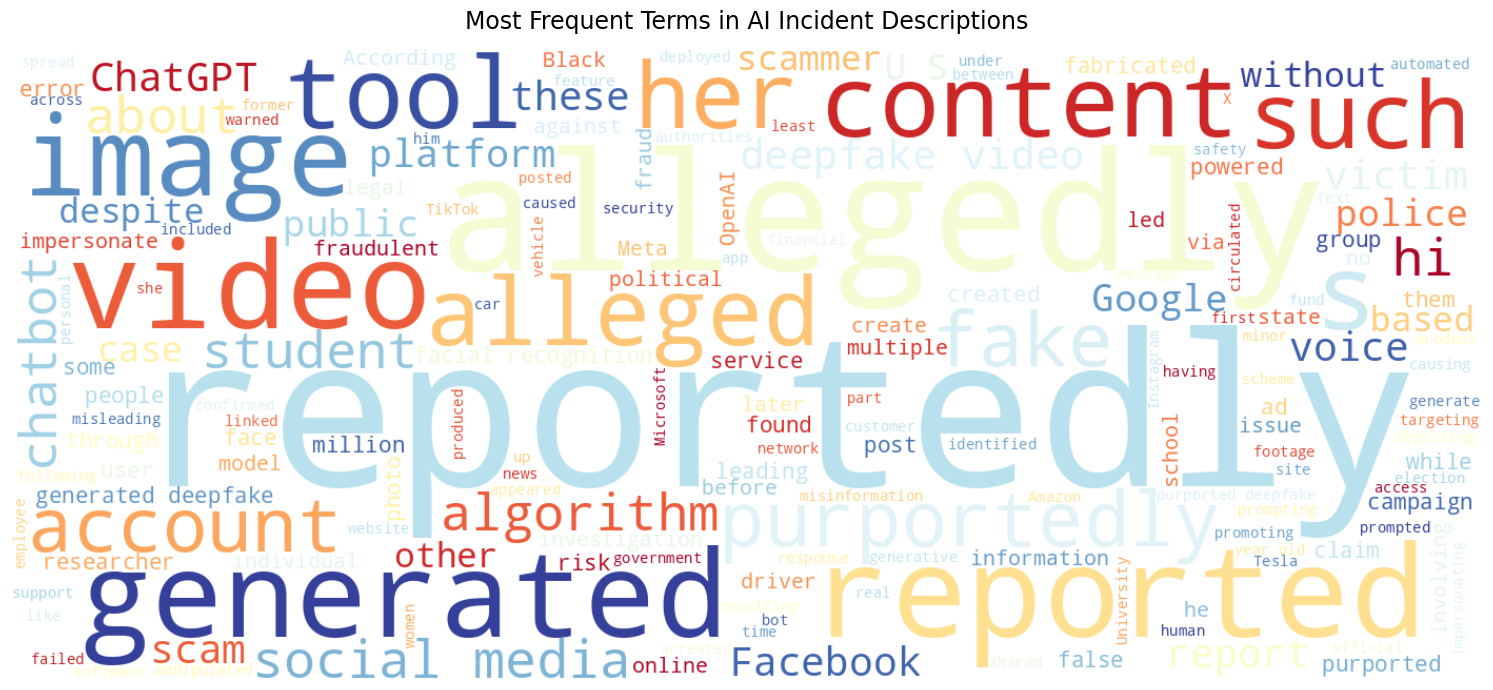

In [ ]:
#@title Word Cloud of Incident Descriptions { display-mode: "form" }

_corpus = " ".join(filtered_df["description"].dropna().tolist())

# Extended stop-word list (standard English + domain-specific noise)
_stop = {
    "a","an","the","and","or","but","in","on","at","to","for","of","with",
    "by","from","is","was","are","were","be","been","being","have","has",
    "had","do","does","did","will","would","could","should","may","might",
    "that","this","it","its","which","who","whom","their","they","also",
    "not","after","when","over","used","using","during","into","use","new",
    "one","two","several","many","using","due","including","as","than","more",
    "system","systems","ai","technology","incident","company","data","users",
}

wc = WordCloud(
    width=1400, height=600,
    background_color="white",
    colormap="RdYlBu_r",
    max_words=180,
    stopwords=_stop,
    collocations=True,
    min_font_size=10,
).generate(_corpus)

fig_wc, ax = plt.subplots(figsize=(18, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Most Frequent Terms in AI Incident Descriptions", fontsize=17, pad=14)
plt.tight_layout()
plt.show()

### Chart 12 — Emerging Risk Shift (2023 Onward vs Historical)

**What this cell does:** Compares the distribution of risk domains before 2023 against 2023 and later. This highlights which categories of AI harm are growing or shrinking as a share of total incidents.

**What it produces:** A grouped bar chart showing the percentage share of each risk domain in the historical period versus the recent period, with percentage-point shifts annotated.

**How to confirm success:** A chart appears with paired bars for each risk domain. Positive shifts indicate growing categories. If MIT data is unavailable, the cell prints a notice.

In [ ]:
#@title Emerging Risk Shift (2023 Onward vs Historical) { display-mode: "form" }

if "risk_domain" in filtered_df.columns:
    _CUT       = 2023
    _hist_s    = filtered_df[filtered_df["year"] <  _CUT]["risk_domain"].dropna()
    _recent_s  = filtered_df[filtered_df["year"] >= _CUT]["risk_domain"].dropna()

    _hist_pct  = _hist_s.value_counts(normalize=True).rename("Pre-2023")
    _rec_pct   = _recent_s.value_counts(normalize=True).rename("2023+")

    _cmp = (
        pd.DataFrame([_hist_pct, _rec_pct]).T.fillna(0).reset_index()
        .rename(columns={"index": "risk_domain"})
    )
    _cmp["shift"] = _cmp["2023+"] - _cmp["Pre-2023"]
    _cmp = _cmp.sort_values("shift", ascending=False)

    # Annotate with absolute counts for context
    _hist_n   = len(_hist_s)
    _recent_n = len(_recent_s)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        name=f"Pre-2023  (n={_hist_n:,})",
        x=_cmp["risk_domain"], y=_cmp["Pre-2023"],
        marker_color="#bfdbfe",
    ))
    fig.add_trace(go.Bar(
        name=f"2023+  (n={_recent_n:,})",
        x=_cmp["risk_domain"], y=_cmp["2023+"],
        marker_color="#1d4ed8",
    ))
    fig.update_layout(
        barmode="group",
        title="Emerging Risk Shift: Share of Incidents by Domain, Historical vs 2023+",
        xaxis_title="Risk Domain",
        yaxis_title="Share of Incidents",
        yaxis_tickformat=".0%",
        template="plotly_white",
        height=490,
        legend=dict(orientation="h", yanchor="bottom", y=1.02),
    )
    fig.show()
else:
    print("'risk_domain' not available.")

## Section 6 — Interactive Web Application (Gradio)

The remaining cells build and launch a self-contained web application that provides a point-and-click interface for exploring the data. It does not require any coding to use.

The application has six tabs:                                                                                                               
- **Incident Explorer** — Search, filter, and inspect individual incidents.
- **Trend Analysis** — Interactive time-series charts with selectable metrics.
- **Entity Deep Dive** — Full incident history for any deployer, developer, or harmed party.
- **Harm Landscape** — Taxonomy, geography, and sector overview charts.
- **High Impact Incidents** — Incidents ranked by media coverage volume.
- **AI Assistant** — Ask any question about AI incidents in plain English. Powered by Qwen3-0.6B with retrieval-augmented generation over the full incident database.

In [ ]:
#@title UI Static Option Lists { display-mode: "form" }

_ui_year_min = int(incidents_df["year"].min())
_ui_year_max = int(incidents_df["year"].max())

_ui_domains   = ["All"] + sorted(incidents_df["risk_domain"].dropna().unique())                 if "risk_domain" in incidents_df.columns else ["All"]
_ui_goals     = ["All"] + sorted(incidents_df["ai_goal"].dropna().unique())                 if "ai_goal"     in incidents_df.columns else ["All"]
_ui_deployers = ["All"] + deployers_df["deployer"].value_counts().head(80).index.tolist()
_ui_harmed    = ["All"] + harmed_df["harmed_party"].value_counts().head(80).index.tolist()

_ui_dep_names    = sorted(deployers_df["deployer"].unique().tolist())
_ui_dev_names    = sorted(developers_df["developer"].unique().tolist())
_ui_harmed_names = sorted(harmed_df["harmed_party"].unique().tolist())

_TREND_METRICS = [
    "Incidents per Year",
    "Risk Domain Composition Over Time",
    "Intent Split Over Time",
    "Top 5 AI Goals Over Time",
    "Media Reports per Year",
    "Top 5 Deployers Over Time",
    "Year-over-Year Growth Rate",
    "Physical Harm Incidents per Year",
]


# Metric card HTML helper

def _stats_banner() -> str:
    n_inc  = len(incidents_df)
    n_rep  = len(reports_df)
    n_dep  = deployers_df["deployer"].nunique()
    d_min  = str(incidents_df["date"].min())[:7]
    d_max  = str(incidents_df["date"].max())[:7]
    _s  = ("background:#f8fafc;border:1px solid #e2e8f0;border-radius:10px;"
           "padding:16px 22px;text-align:center;")
    def _card(val, color, label):
        return (
            f'<div style="{_s}">'
            f'<p style="font-size:26px;font-weight:700;color:{color};margin:0;">{val}</p>'
            f'<p style="font-size:12px;color:#64748b;margin:4px 0 0;">{label}</p>'
            '</div>'
        )
    return (
        '<div style="display:grid;grid-template-columns:repeat(4,1fr);'
        'gap:12px;padding:4px 0 10px;">'
        + _card(f"{n_inc:,}", "#1d4ed8", "Total Incidents")
        + _card(f"{n_rep:,}", "#15803d", "Media Reports")
        + _card(f"{n_dep:,}", "#b45309", "Unique Deployers")
        + _card(f"{d_min} to {d_max}", "#9d174d", "Date Range")
        + '</div>'
    )


# Backend functions

def ui_search(keyword, year_start, year_end, risk_domain, ai_goal, deployer, harmed):
    """Tab 1: filter incidents and return display table + status + state."""
    mask = incidents_df["year"].between(year_start, year_end)
    if risk_domain != "All" and "risk_domain" in incidents_df.columns:
        mask &= incidents_df["risk_domain"] == risk_domain
    if ai_goal != "All" and "ai_goal" in incidents_df.columns:
        mask &= incidents_df["ai_goal"] == ai_goal
    if deployer != "All":
        ids   = deployers_df[deployers_df["deployer"]     == deployer]["incident_id"]
        mask &= incidents_df["incident_id"].isin(ids)
    if harmed != "All":
        ids   = harmed_df[harmed_df["harmed_party"]       == harmed]["incident_id"]
        mask &= incidents_df["incident_id"].isin(ids)
    if keyword.strip():
        kw    = keyword.strip().lower()
        mask &= (
            incidents_df["title"].str.lower().str.contains(kw, na=False) |
            incidents_df["description"].str.lower().str.contains(kw, na=False)
        )
    result   = incidents_df[mask].copy()
    out_cols = [c for c in ["incident_id","date","title","risk_domain","ai_goal",
                             "intent","report_count","description"]
                if c in result.columns]
    result["date"] = result["date"].astype(str)
    display_df     = result[out_cols].head(500)
    status         = f"{len(result):,} incident(s) matched"
    return display_df, status, display_df.to_dict("records")


def ui_show_detail(evt: gr.SelectData, state: list):
    """Tab 1: render full incident details when a table row is selected."""
    if not state:
        return "<p style='color:#94a3b8;'>Select a row to view details.</p>"
    df = pd.DataFrame(state)
    if evt.index[0] >= len(df):
        return ""
    inc_id = df.iloc[evt.index[0]].get("incident_id")
    row    = incidents_df[incidents_df["incident_id"] == inc_id]
    if row.empty:
        return ""
    r      = row.iloc[0]
    domain = r.get("risk_domain", "")
    sector = r.get("Sector of Deployment", "")
    goal   = r.get("ai_goal", "")
    intent = r.get("intent", "")
    harm   = r.get("AI Harm Level", "")
    rcount = r.get("report_count", "")
    deployer_list = ", ".join(r.get("deployers_raw", []) or [])
    harmed_list   = ", ".join(r.get("harmed_raw",    []) or [])
    def _row(label, value):
        if not value or (isinstance(value, float) and np.isnan(value)):
            return ""
        return (f"<tr><td style='color:#64748b;padding:4px 12px 4px 0;white-space:nowrap;"
                f"font-size:13px;'>{label}</td>"
                f"<td style='color:#1e293b;font-size:13px;padding:4px 0;'>{value}</td></tr>")
    rows_html = "".join([
        _row("Date",         str(r.get("date",""))[:10]),
        _row("Risk Domain",  domain),
        _row("AI Goal",      goal),
        _row("Intent",       intent),
        _row("Harm Level",   harm),
        _row("Sector",       sector),
        _row("Reports",      rcount),
        _row("Deployers",    deployer_list),
        _row("Harmed",       harmed_list),
    ])
    desc      = r.get("description", "No description available.")
    title_txt = str(r.get("title", ""))
    return (
        '<div style="border:1px solid #e2e8f0;border-radius:10px;padding:20px;'
        'background:#f8fafc;font-family:sans-serif;margin-top:8px;">'
        + f'<h3 style="margin:0 0 6px;color:#0f172a;font-size:16px;">#{inc_id} — {title_txt}</h3>'
        + '<table style="border-collapse:collapse;margin-bottom:12px;">'
        + rows_html
        + '</table>'
        + f'<p style="color:#334155;line-height:1.65;font-size:13px;margin:0;">{desc}</p>'
        + '</div>'
    )


def ui_export(state: list):
    """Tab 1: export current results to CSV and return file path."""
    if not state:
        return None
    path = "/tmp/aiid_filtered_export.csv"
    pd.DataFrame(state).to_csv(path, index=False)
    return path


def ui_trend(metric: str):
    """Produces a Plotly figure for the selected trend metric with safety checks."""
    df = incidents_df.copy()
    fig = None

    # Helper to prevent crashes on empty selections
    if df.empty:
        fig = go.Figure()
        fig.update_layout(title="No data available in dataset", template="plotly_white")
        return fig

    if metric == "Incidents per Year":
        agg = df.groupby("year").size().reset_index(name="count")
        agg = agg[agg["year"].notna()].sort_values("year")
        agg["rolling"] = agg["count"].rolling(3, center=True, min_periods=1).mean()
        fig = px.bar(agg, x="year", y="count", template="plotly_white",
                     title="Incidents per Year", labels={"count":"Count","year":"Year"},
                     color_discrete_sequence=["#93c5fd"])
        fig.add_scatter(x=agg["year"], y=agg["rolling"], mode="lines",
                        name="3-yr rolling avg", line=dict(color="#1d4ed8", width=2.5))

    elif metric == "Risk Domain Composition Over Time" and "risk_domain" in df.columns:
        agg = (df[["year","risk_domain"]].dropna()
               .query("year >= 2010")
               .groupby(["year","risk_domain"]).size().reset_index(name="count"))
        fig = px.area(agg, x="year", y="count", color="risk_domain",
                      template="plotly_white", title="Risk Domain Composition Over Time",
                      color_discrete_sequence=px.colors.qualitative.Safe)

    elif metric == "Intent Split Over Time" and "intent" in df.columns:
        agg = (df[["year","intent"]].dropna()
               .query("year >= 2010")
               .groupby(["year","intent"]).size().reset_index(name="count"))
        fig = px.area(agg, x="year", y="count", color="intent",
                      template="plotly_white",
                      title="Intent Split Over Time",
                      color_discrete_map={"Intentional":"#ef4444",
                                          "Unintentional":"#3b82f6","Other":"#9ca3af"})

    elif metric == "Top 5 AI Goals Over Time" and "ai_goal" in df.columns:
        top5 = df["ai_goal"].value_counts().head(5).index
        agg = (df[df["ai_goal"].isin(top5)][["year","ai_goal"]]
               .dropna().query("year >= 2010")
               .groupby(["year","ai_goal"]).size().reset_index(name="count"))
        fig = px.line(agg, x="year", y="count", color="ai_goal", markers=True,
                    template="plotly_white", title="Top 5 AI Goals Over Time")

    elif metric == "Media Reports per Year" and "date_published" in reports_df.columns:
      rdf  = reports_df.copy()
      rdf["year"] = rdf["date_published"].dt.year
      agg  = rdf.groupby("year").size().reset_index(name="count")
      agg  = agg[agg["year"].between(1995, _ui_year_max + 1)]
      fig  = px.bar(agg, x="year", y="count", template="plotly_white",
                    title="Media Reports Filed per Year",
                    color_discrete_sequence=["#6ee7b7"])

    elif metric == "Top 5 Deployers Over Time":
        # FIX: Direct selection to avoid .assign() index mismatch
        top5 = deployers_df["deployer"].value_counts().head(5).index
        agg = (deployers_df[deployers_df["deployer"].isin(top5)][["year", "deployer"]]
               .groupby(["year", "deployer"]).size().reset_index(name="count")
               .sort_values("year"))
        fig = px.line(agg, x="year", y="count", color="deployer", markers=True,
                      template="plotly_white", title="Top 5 Deployers Over Time")

    elif metric == "Year-over-Year Growth Rate":
        agg = df.groupby("year").size().reset_index(name="count").sort_values("year")
        agg["yoy"] = agg["count"].pct_change() * 100
        agg = agg[agg["year"].notna() & agg["year"].between(1992, _ui_year_max)]
        fig = px.bar(agg, x="year", y="yoy", template="plotly_white",
                     title="Year-over-Year Incident Growth Rate (%)",
                     labels={"yoy":"Growth %","year":"Year"},
                     color="yoy", color_continuous_scale="RdYlGn",
                     color_continuous_midpoint=0)
    elif metric == "Physical Harm Incidents per Year" and "has_physical_harm" in df.columns:
        agg = (df[df["has_physical_harm"] == True]
               .groupby("year").size().reset_index(name="count"))
        fig = px.bar(agg, x="year", y="count", template="plotly_white",
                     title="Incidents with Confirmed Physical Harm (CSET)",
                     labels={"count":"Incidents","year":"Year"},
                     color_discrete_sequence=["#dc2626"])

    # Fallback for missing columns or unhandled metrics
    if fig is None:
        fig = go.Figure()
        fig.update_layout(
            title=f"Metric '{metric}' could not be rendered (Missing columns or data)",
            template="plotly_white"
        )

    fig.update_layout(height=500, margin=dict(l=20, r=20, t=60, b=20), hovermode="x unified")
    return fig


def ui_entity_choices(entity_type: str):
    """Tab 3: update entity name dropdown when type changes."""
    if entity_type == "Developer":
        return gr.update(choices=_ui_dev_names, value=_ui_dev_names[0] if _ui_dev_names else None)
    if entity_type == "Harmed Party":
        return gr.update(choices=_ui_harmed_names, value=_ui_harmed_names[0] if _ui_harmed_names else None)
    return gr.update(choices=_ui_dep_names, value=_ui_dep_names[0] if _ui_dep_names else None)


def ui_entity_dive(entity_type: str, entity_name: str):
    """Tab 3: summary card + timeline + harm pie + top incidents table."""
    if entity_type == "Deployer":
        ids = deployers_df[deployers_df["deployer"]     == entity_name]["incident_id"]
    elif entity_type == "Developer":
        ids = developers_df[developers_df["developer"]  == entity_name]["incident_id"]
    else:
        ids = harmed_df[harmed_df["harmed_party"]       == entity_name]["incident_id"]

    subset = incidents_df[incidents_df["incident_id"].isin(ids)].copy()
    if subset.empty:
        blank = go.Figure()
        blank.update_layout(title=f"No incidents found for '{entity_name}'",
                            template="plotly_white")
        return (
            f"<p>No data found for <b>{entity_name}</b> as {entity_type}.</p>",
            blank, blank,
            pd.DataFrame(),
        )

    n_inc     = len(subset)
    d_range   = f"{str(subset['date'].min())[:10]} to {str(subset['date'].max())[:10]}"
    top_harm  = (subset["risk_domain"].mode().iloc[0]
                 if "risk_domain" in subset.columns and not subset["risk_domain"].isna().all()
                 else "N/A")
    med_cov   = f"{subset['report_count'].median():.0f}" if "report_count" in subset.columns else "N/A"

    _g = "display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-top:10px;"
    def _ec(val, size, label):
        return (f'<div><div style="font-size:{size};font-weight:700;color:#0369a1;">{val}</div>'
                f'<div style="font-size:11px;color:#64748b;">{label}</div></div>')
    stats_html = (
        '<div style="background:#f0f9ff;border:1px solid #bae6fd;border-radius:8px;'
        'padding:14px 18px;font-family:sans-serif;margin-bottom:4px;">'
        + f'<b style="font-size:15px;color:#0c4a6e;">{entity_name}</b>'
        + f'<span style="color:#64748b;font-size:13px;"> ({entity_type})</span>'
        + f'<div style="{_g}">'
        + _ec(n_inc, "22px", "Incidents")
        + _ec(d_range, "13px", "Date range")
        + _ec(top_harm[:40], "12px", "Primary harm domain")
        + _ec(med_cov, "22px", "Median reports/incident")
        + '</div></div>'
    )

    # Timeline
    yr_cnt  = subset.groupby("year").size().reset_index(name="count")
    fig_t   = px.bar(yr_cnt, x="year", y="count",
                     title=f"Incident Timeline — {entity_name}",
                     labels={"count":"Incidents","year":"Year"},
                     color_discrete_sequence=["#3b82f6"],
                     template="plotly_white")
    fig_t.update_layout(height=320)

    # Harm breakdown
    if "risk_domain" in subset.columns and subset["risk_domain"].notna().any():
        hc     = subset["risk_domain"].value_counts().reset_index()
        hc.columns = ["domain","count"]
        fig_p  = px.pie(hc, values="count", names="domain",
                        title=f"Harm Type Breakdown — {entity_name}",
                        template="plotly_white",
                        color_discrete_sequence=px.colors.qualitative.Safe)
        fig_p.update_traces(textinfo="percent+label")
        fig_p.update_layout(height=320)
    else:
        fig_p = go.Figure()
        fig_p.update_layout(title="Risk domain data not available",
                            template="plotly_white", height=320)

    # Top incidents table
    top_cols = [c for c in ["incident_id","date","title","risk_domain","report_count"]
                if c in subset.columns]
    sort_col = "report_count" if "report_count" in top_cols else top_cols[0]
    top_tbl  = subset[top_cols].sort_values(sort_col, ascending=False).head(15).copy()
    top_tbl["date"] = top_tbl["date"].astype(str)

    return stats_html, fig_t, fig_p, top_tbl


def ui_harm_landscape():
    """Tab 4: sunburst chart — auto-loaded on tab open."""
    if "risk_domain" in incidents_df.columns and "risk_subdomain" in incidents_df.columns:
        sun = (
            incidents_df[["risk_domain","risk_subdomain"]]
            .dropna(subset=["risk_domain"])
            .assign(risk_subdomain=lambda x: x["risk_subdomain"].fillna("(unclassified)"))
            .groupby(["risk_domain","risk_subdomain"]).size()
            .reset_index(name="count")
        )
        fig = px.sunburst(sun, path=["risk_domain","risk_subdomain"], values="count",
                          title="AI Harm Landscape — MIT Taxonomy (full dataset)",
                          color="count", color_continuous_scale="Reds",
                          template="plotly_white")
        fig.update_traces(textinfo="label+percent parent")
        fig.update_layout(height=640)
        return fig
    fig = go.Figure()
    fig.update_layout(title="MIT taxonomy not available", template="plotly_white")
    return fig


def ui_geo_chart():
    """Tab 4: choropleth — auto-loaded on tab open."""
    if "country_code" not in incidents_df.columns:
        return go.Figure()
    geo = incidents_df["country_code"].dropna().value_counts().reset_index()
    geo.columns = ["country_code","count"] if geo.columns[0] != "count" else ["count","country_code"]
    if geo.columns[0] == "count":
        geo = geo[["country_code","count"]]
    cc  = coco.CountryConverter()
    geo["iso3"] = cc.convert(names=geo["country_code"].tolist(), to="ISO3")
    geo = geo[geo["iso3"] != "not found"]
    fig = px.choropleth(geo, locations="iso3", color="count",
                        hover_name="country_code",
                        color_continuous_scale="YlOrRd",
                        title="Geographic Distribution (CSET, partial coverage)",
                        template="plotly_white")
    fig.update_layout(height=440, geo=dict(showframe=False))
    return fig


def ui_sector_chart():
    """Tab 4: sector breakdown — auto-loaded on tab open."""
    col = "Sector of Deployment"
    if col not in incidents_df.columns:
        return go.Figure()
    sec = incidents_df[col].dropna().value_counts().head(15).reset_index()
    sec.columns = ["sector","count"]
    fig = px.bar(sec, x="count", y="sector", orientation="h",
                 title="Top 15 Deployment Sectors (CSET)",
                 labels={"count":"Incidents","sector":"Sector"},
                 color="count", color_continuous_scale="Blues",
                 template="plotly_white")
    fig.update_layout(height=480, yaxis=dict(categoryorder="total ascending"),
                      coloraxis_showscale=False)
    return fig


def ui_high_impact(top_n: int):
    """Tab 5: table and chart of the N most-covered incidents."""
    col  = "report_count"
    cols = [c for c in ["incident_id","title","year","risk_domain","ai_goal","report_count","description"]
            if c in incidents_df.columns]
    if col not in incidents_df.columns:
        return pd.DataFrame({"message":["report_count not available"]}), go.Figure()

    top  = incidents_df.nlargest(int(top_n), col)[cols].copy()
    top["date_str"] = incidents_df.loc[top.index, "date"].astype(str)
    top["label"]    = top["title"].str[:70]
    top_disp        = top.drop(columns=["label"], errors="ignore")
    top_disp["description"] = top_disp["description"].str[:120] + "..."

    fig = px.bar(
        top.head(20), x=col, y="label", orientation="h",
        color="risk_domain" if "risk_domain" in top.columns else None,
        title=f"Top {int(top_n)} Incidents by Media Coverage",
        labels={col:"Number of Reports","label":"Incident",
                "risk_domain":"Risk Domain"},
        template="plotly_white",
        color_discrete_sequence=px.colors.qualitative.Safe,
    )
    fig.update_layout(height=max(420, int(top_n) * 24),
                      yaxis=dict(categoryorder="total ascending"), showlegend=True)
    return top_disp, fig

In [ ]:
#@title RAG Setup { display-mode: "form" }

# Corpus: one document per incident (title + description)
# Embeddings: all-MiniLM-L6-v2  (22M params, 384-dim, ~10s for 1,400 docs on T4)
# Retrieval:  FAISS IndexFlatIP  (cosine similarity on L2-normalised vectors)
# Generation: Qwen/Qwen3-0.6B   (600M params, 32K ctx, chat-template, ~2-3s/query on T4)

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

_rag_corpus_ids  = incidents_df["incident_id"].tolist()
_rag_corpus_docs = [
    str(row["title"]) + ". " + str(row["description"])
    for _, row in incidents_df[["incident_id","title","description"]].iterrows()
]

print("Loading embedding model...")
_rag_embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Encoding corpus...")
_rag_embeddings = _rag_embedder.encode(
    _rag_corpus_docs, batch_size=64, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)

print("Building FAISS index...")
_rag_index = faiss.IndexFlatIP(_rag_embeddings.shape[1])
_rag_index.add(_rag_embeddings)

print("Loading Qwen3-0.6B...")
_rag_model_id  = "Qwen/Qwen3-0.6B"
_rag_tokenizer = AutoTokenizer.from_pretrained(_rag_model_id)
_rag_model     = AutoModelForCausalLM.from_pretrained(
    _rag_model_id,
    torch_dtype="auto",
    device_map="auto",
)
_rag_model.eval()
print("RAG ready.")


def rag_answer(question: str, top_k: int = 15) -> tuple:
    # Returns (answer_text, retrieved_incidents)
    q_vec = _rag_embedder.encode(
        [question], convert_to_numpy=True, normalize_embeddings=True
    )
    scores, indices = _rag_index.search(q_vec, top_k)

    ctx_rows = []
    context_parts = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
        inc_id = _rag_corpus_ids[idx]
        row = incidents_df[incidents_df["incident_id"] == inc_id].iloc[0]
        deployer = (
            row.get("deployers_clean", ["unknown"])[0]
            if isinstance(row.get("deployers_clean"), list)
            else "unknown"
        )
        domain = row.get("risk_domain", "")
        harm_text = (
            f"Incident #{inc_id} ({row['date'].year if pd.notna(row['date']) else '?'}): "
            f"{row['title']}. {str(row['description'])[:250]}. "
            f"[Deployer: {deployer} | Domain: {domain}]"
        )
        context_parts.append(f"[{rank}] {harm_text}")
        ctx_rows.append({
            "Rank": rank,
            "Incident ID": inc_id,
            "Title": row["title"],
            "Year": int(row["date"].year) if pd.notna(row.get("date")) else "?",
            "Deployer": deployer,
            "Risk Domain": domain,
            "Score": round(float(score), 3),
        })

    context = "\n".join(context_parts)
    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI safety researcher with deep knowledge of AI incidents. "
                "Answer questions using only the provided incident records. "
                "Be concise, specific, and cite incident IDs where relevant."
            ),
        },
        {
            "role": "user",
            "content": "Incident records:\n" + context + "\n\nQuestion: " + question,
        },
    ]
    # enable_thinking=False skips the reasoning chain for faster responses
    text = _rag_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    inputs = _rag_tokenizer([text], return_tensors="pt").to(_rag_model.device)
    with torch.no_grad():
        out = _rag_model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            pad_token_id=_rag_tokenizer.eos_token_id,
        )
    # Decode only the newly generated tokens
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    answer = _rag_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return answer, ctx_rows

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding corpus...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Building FAISS index...
Loading Qwen3-0.6B...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


RAG ready.


In [ ]:
#@title Gradio App { display-mode: "form" }

with gr.Blocks(title="AIID Explorer", theme=gr.themes.Soft()) as demo:

    gr.HTML(_stats_banner())

    gr.Markdown(
        "## AI Incident Database Explorer\n"
        "Interactive analysis of documented AI harms.  "
        "Data: [AI Incident Database](https://incidentdatabase.ai/) — CC BY-SA 4.0."
    )

    with gr.Tabs():

        # Tab 1: Incident Explorer
        with gr.Tab("Incident Explorer"):
            gr.Markdown(
                "Search and filter all incidents. Click any row for full details."
            )
            with gr.Row():
                t1_kw    = gr.Textbox(label="Keyword Search",
                                      placeholder="autonomous vehicle, deepfake...", scale=3)
                t1_dom   = gr.Dropdown(choices=_ui_domains,   value="All",
                                       label="Risk Domain", scale=2)
                t1_goal  = gr.Dropdown(choices=_ui_goals,     value="All",
                                       label="AI Goal", scale=2)
            with gr.Row():
                t1_dep   = gr.Dropdown(choices=_ui_deployers, value="All",
                                       label="Deployer", scale=2)
                t1_harm  = gr.Dropdown(choices=_ui_harmed,    value="All",
                                       label="Harmed Party", scale=2)
                t1_y1    = gr.Slider(_ui_year_min, _ui_year_max,
                                     value=_ui_year_min, step=1, label="Year From", scale=1)
                t1_y2    = gr.Slider(_ui_year_min, _ui_year_max,
                                     value=_ui_year_max, step=1, label="Year To", scale=1)
            with gr.Row():
                t1_btn    = gr.Button("Search", variant="primary")
                t1_exp    = gr.Button("Export CSV")
                t1_status = gr.Textbox(label="", interactive=False, scale=4)
            t1_state  = gr.State([])
            t1_table  = gr.Dataframe(label="Results", interactive=False,
                                     wrap=True)
            t1_detail = gr.HTML("<p style='color:#94a3b8;font-size:13px;'>"
                                "Select a row above to view full incident details.</p>")
            t1_file   = gr.File(label="Download", visible=False)

            t1_btn.click(
                fn=ui_search,
                inputs=[t1_kw, t1_y1, t1_y2, t1_dom, t1_goal, t1_dep, t1_harm],
                outputs=[t1_table, t1_status, t1_state],
            )
            t1_table.select(fn=ui_show_detail, inputs=[t1_state], outputs=t1_detail)
            t1_exp.click(fn=ui_export, inputs=[t1_state],
                         outputs=gr.File(label="Download", visible=True))

        # Tab 2: Trend Analysis
        with gr.Tab("Trend Analysis"):
            gr.Markdown(
                "Select a metric to chart AI incident trends over time."
            )
            t2_metric = gr.Dropdown(
                choices=_TREND_METRICS, value=_TREND_METRICS[0],
                label="Metric",
            )
            t2_btn  = gr.Button("Generate Chart", variant="primary")
            t2_plot = gr.Plot(label="Trend Chart")
            t2_btn.click(fn=ui_trend, inputs=[t2_metric], outputs=t2_plot)

        # Tab 3: Entity Deep Dive
        with gr.Tab("Entity Deep Dive"):
            gr.Markdown(
                "Examine the full incident history of any deployer, developer, or harmed party."
            )
            with gr.Row():
                t3_type   = gr.Dropdown(
                    choices=["Deployer","Developer","Harmed Party"],
                    value="Deployer", label="Entity Type",
                )
                t3_entity = gr.Dropdown(
                    choices=_ui_dep_names,
                    value=_ui_dep_names[0] if _ui_dep_names else None,
                    label="Select Entity", interactive=True,
                )
            t3_type.change(fn=ui_entity_choices, inputs=t3_type, outputs=t3_entity)
            t3_btn    = gr.Button("Analyze", variant="primary")
            t3_stats  = gr.HTML()
            with gr.Row():
                t3_timeline = gr.Plot(label="Incident Timeline")
                t3_pie      = gr.Plot(label="Harm Type Breakdown")
            t3_table = gr.Dataframe(label="Top Incidents", interactive=False)
            t3_btn.click(
                fn=ui_entity_dive,
                inputs=[t3_type, t3_entity],
                outputs=[t3_stats, t3_timeline, t3_pie, t3_table],
            )

        # Tab 4: Harm Landscape
        with gr.Tab("Harm Landscape"):
            gr.Markdown(
                "Full-dataset overview — taxonomy, geography, and deployment sectors. "
                "Click **Load** to render all charts."
            )
            t4_btn     = gr.Button("Load Harm Landscape", variant="primary")
            t4_sunburst= gr.Plot(label="MIT Risk Taxonomy Sunburst")
            with gr.Row():
                t4_geo  = gr.Plot(label="Geographic Distribution")
                t4_sec  = gr.Plot(label="Deployment Sectors")
            t4_btn.click(
                fn=lambda: (ui_harm_landscape(), ui_geo_chart(), ui_sector_chart()),
                inputs=[],
                outputs=[t4_sunburst, t4_geo, t4_sec],
            )

        # Tab 5: High Impact Incidents
        with gr.Tab("High Impact Incidents"):
            gr.Markdown(
                "Incidents ranked by the volume of media reports. "
                "High report count indicates significant editorial attention."
            )
            t5_n   = gr.Slider(10, 50, value=20, step=5, label="Number of Incidents to Show")
            t5_btn = gr.Button("Load", variant="primary")
            t5_tbl = gr.Dataframe(label="Top Incidents", interactive=False)
            t5_fig = gr.Plot(label="Coverage Chart")
            t5_btn.click(fn=ui_high_impact, inputs=[t5_n], outputs=[t5_tbl, t5_fig])

        # Tab 6: AI Assistant (RAG)
        with gr.Tab("AI Assistant"):
            gr.Markdown(
                "Ask any question about AI incidents. "
                "The assistant retrieves the most relevant incidents and answers using "
                "[Qwen3-0.6B](https://huggingface.co/Qwen/Qwen3-0.6B) (32K context) + "
                "[all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) embeddings."
            )
            t6_chatbot  = gr.Chatbot(label="Chat", height=420, bubble_full_width=False)
            with gr.Row():
                t6_input = gr.Textbox(
                    placeholder="e.g. Which deployers caused the most physical harm?",
                    label="Your question", scale=5,
                )
                t6_top_k = gr.Slider(5, 25, value=15, step=5, label="Retrieved incidents", scale=1)
            with gr.Row():
                t6_send  = gr.Button("Ask", variant="primary")
                t6_clear = gr.Button("Clear")
            t6_ctx   = gr.Dataframe(
                label="Retrieved incident context",
                interactive=False, visible=False,
            )
            t6_ctx_toggle = gr.Checkbox(label="Show retrieved incidents", value=False)

            def _rag_chat(message, history, top_k, ctx_visible):
                if not message.strip():
                    return history, gr.update(), gr.update(visible=ctx_visible)
                answer, ctx_rows = rag_answer(message, top_k=int(top_k))
                history = history + [[message, answer]]
                ctx_df  = __import__("pandas").DataFrame(ctx_rows)
                return history, ctx_df, gr.update(visible=ctx_visible)

            t6_send.click(
                fn=_rag_chat,
                inputs=[t6_input, t6_chatbot, t6_top_k, t6_ctx_toggle],
                outputs=[t6_chatbot, t6_ctx, t6_ctx],
            ).then(lambda: "", outputs=t6_input)

            t6_input.submit(
                fn=_rag_chat,
                inputs=[t6_input, t6_chatbot, t6_top_k, t6_ctx_toggle],
                outputs=[t6_chatbot, t6_ctx, t6_ctx],
            ).then(lambda: "", outputs=t6_input)

            t6_clear.click(lambda: ([], None), outputs=[t6_chatbot, t6_ctx])

            t6_ctx_toggle.change(
                fn=lambda show, df: gr.update(visible=show),
                inputs=[t6_ctx_toggle, t6_ctx],
                outputs=t6_ctx,
            )

    gr.Markdown(
        "---\n"
        "Data licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).  "
        "Built for TAI Hackathon — Problem Statement 5."
    )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://88abef9693c3fbbb85.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
